<a href="https://colab.research.google.com/github/YosukeMiki/Sagittarius-Repository/blob/main/260610_01_%E3%82%A4%E3%82%AE%E3%83%AA%E3%82%B9%E3%81%AE%E3%82%AA%E3%83%B3%E3%83%A9%E3%82%A4%E3%83%B3%E3%82%B7%E3%83%A7%E3%83%83%E3%83%94%E3%83%B3%E3%82%B0%E8%B3%BC%E8%B2%B7%E3%83%87%E3%83%BC%E3%82%BF%E5%88%86%E6%9E%90_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -q https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip
!unzip -o online+retail+ii.zip

Archive:  online+retail+ii.zip
 extracting: online_retail_II.xlsx   


In [ ]:
import pandas as pd

# 2つのシート（2009-2010年・2010-2011年）をまとめて読み込む
sheets = pd.read_excel("online_retail_II.xlsx", sheet_name=None)
df = pd.concat(sheets.values(), ignore_index=True)

print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
len(df)

1067371

In [ ]:
import duckdb
duckdb.sql("SELECT COUNT(*) AS total_rows FROM df").df()

,total_rows
0,1067371


In [ ]:
duckdb.sql("""
    SELECT
      COUNT(*)                                              AS total,
      COUNT(*) FILTER (WHERE "Customer ID" IS NULL)         AS missing_customer,
      COUNT(*) FILTER (WHERE CAST(Invoice AS VARCHAR) LIKE 'C%') AS cancellations,
      COUNT(*) FILTER (WHERE Quantity <= 0)                 AS non_positive_qty,
      COUNT(*) FILTER (WHERE Price <= 0)                    AS non_positive_price
    FROM df
""").df()

,total,missing_customer,cancellations,non_positive_qty,non_positive_price
0,1067371,243007,19494,22950,6207


In [ ]:
df_clean = duckdb.sql("""
    SELECT *
    FROM df
    WHERE "Customer ID" IS NOT NULL
      AND Quantity > 0
      AND Price    > 0
""").df()

print(df_clean.shape)

(805549, 8)


In [ ]:
duckdb.sql("""
    SELECT
      COUNT(*)                                              AS total,
      COUNT(*) FILTER (WHERE "Customer ID" IS NULL)         AS missing_customer,
      COUNT(*) FILTER (WHERE CAST(Invoice AS VARCHAR) LIKE 'C%') AS cancellations,
      COUNT(*) FILTER (WHERE Quantity <= 0)                 AS non_positive_qty,
      COUNT(*) FILTER (WHERE Price <= 0)                    AS non_positive_price
    FROM df_clean
""").df()

,total,missing_customer,cancellations,non_positive_qty,non_positive_price
0,805549,0,0,0,0


In [ ]:
customers = duckdb.sql("""
    SELECT
      CAST("Customer ID" AS BIGINT)                          AS customer_id,
      COUNT(DISTINCT Invoice)                                AS orders,
      SUM(Quantity)                                          AS total_units,
      ROUND(SUM(Quantity * Price), 2)                        AS total_spend,
      COUNT(DISTINCT StockCode)                              AS distinct_items,
      MAX(Quantity)                                          AS max_line_qty,
      ROUND(SUM(Quantity) * 1.0 / COUNT(DISTINCT Invoice), 1) AS units_per_order
    FROM df_clean
    GROUP BY customer_id
""").df()

print(customers.shape)
customers.head()

(5878, 7)


,customer_id,orders,total_units,total_spend,distinct_items,max_line_qty,units_per_order
0,12682,52,11018.0,24033.91,327,216,211.9
1,18087,17,7775.0,14761.52,44,3906,457.4
2,13635,4,1884.0,2999.16,135,48,471.0
3,17519,15,3414.0,5109.47,142,96,227.6
4,12362,11,2230.0,5356.23,201,36,202.7


In [ ]:
duckdb.sql("""
    SELECT customer_id, orders, total_units, total_spend, max_line_qty
    FROM customers
    ORDER BY total_units DESC
    LIMIT 10
""").df()

,customer_id,orders,total_units,total_spend,max_line_qty
0,14646,151,367193.0,528602.52,2400
1,13902,5,220600.0,34095.26,19152
2,13694,143,189205.0,196482.81,1600
3,18102,145,188340.0,608821.65,1008
4,14156,156,165992.0,313946.37,1440
5,14911,398,149987.0,295972.63,640
6,17511,60,119656.0,175603.55,600
7,16684,55,104810.0,147142.77,1152
8,14298,82,100272.0,91194.49,900
9,12415,28,91447.0,144458.37,1152


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

features = ["orders", "total_units", "total_spend",
            "distinct_items", "max_line_qty", "units_per_order"]
X = customers[features].copy()

# ① 対数変換で極端な偏りをならし、② 標準化で単位をそろえる
X_log    = np.log1p(X)
X_scaled = StandardScaler().fit_transform(X_log)

# ③ K-meansで2グループに分ける（業者 vs 消費者 の仮説）
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
customers["cluster"] = kmeans.fit_predict(X_scaled)

customers["cluster"].value_counts()

,count
cluster,
0,3127
1,2751


In [ ]:
duckdb.sql("""
    SELECT
      cluster,
      COUNT(*)                       AS n_customers,
      ROUND(AVG(orders), 1)          AS avg_orders,
      ROUND(AVG(total_units), 0)     AS avg_units,
      ROUND(AVG(total_spend), 0)     AS avg_spend,
      ROUND(AVG(max_line_qty), 0)    AS avg_max_line_qty,
      ROUND(AVG(units_per_order), 1) AS avg_units_per_order
    FROM customers
    GROUP BY cluster
    ORDER BY avg_spend DESC
""").df()

,cluster,n_customers,avg_orders,avg_units,avg_spend,avg_max_line_qty,avg_units_per_order
0,1,2751,11.2,3629.0,5910.0,221.0,381.8
1,0,3127,2.0,231.0,475.0,36.0,136.1


In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"k={k}: silhouette = {sil:.3f}")

k=2: silhouette = 0.374
k=3: silhouette = 0.294
k=4: silhouette = 0.254
k=5: silhouette = 0.255
k=6: silhouette = 0.238


In [ ]:
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
customers["cluster3"] = kmeans3.fit_predict(X_scaled)

duckdb.sql("""
    SELECT
      cluster3,
      COUNT(*)                       AS n_customers,
      ROUND(AVG(orders), 1)          AS avg_orders,
      ROUND(AVG(total_units), 0)     AS avg_units,
      ROUND(AVG(total_spend), 0)     AS avg_spend,
      ROUND(AVG(max_line_qty), 0)    AS avg_max_line_qty,
      ROUND(AVG(units_per_order), 1) AS avg_units_per_order
    FROM customers
    GROUP BY cluster3
    ORDER BY avg_spend DESC
""").df()

,cluster3,n_customers,avg_orders,avg_units,avg_spend,avg_max_line_qty,avg_units_per_order
0,0,1697,15.5,5357.0,8703.0,306.0,448.4
1,1,2795,3.1,531.0,937.0,61.0,220.7
2,2,1386,1.5,95.0,257.0,22.0,70.9


In [ ]:
duckdb.sql("""
    SELECT
      ROUND(quantile_cont(max_line_qty, 0.50), 0) AS p50,
      ROUND(quantile_cont(max_line_qty, 0.75), 0) AS p75,
      ROUND(quantile_cont(max_line_qty, 0.90), 0) AS p90,
      ROUND(quantile_cont(max_line_qty, 0.95), 0) AS p95,
      ROUND(quantile_cont(max_line_qty, 0.99), 0) AS p99,
      MAX(max_line_qty)                            AS max_val
    FROM customers
""").df()

,p50,p75,p90,p95,p99,max_val
0,48.0,80.0,144.0,288.0,1008.0,80995


In [ ]:
duckdb.sql("""
    SELECT
      t.threshold,
      COUNT(*) FILTER (WHERE c.max_line_qty >= t.threshold) AS wholesalers,
      COUNT(*) FILTER (WHERE c.max_line_qty <  t.threshold) AS consumers
    FROM customers c
    CROSS JOIN (SELECT unnest([100, 200, 300, 500, 1000]) AS threshold) t
    GROUP BY t.threshold
    ORDER BY t.threshold
""").df()

,threshold,wholesalers,consumers
0,100,1137,4741
1,200,462,5416
2,300,206,5672
3,500,138,5740
4,1000,64,5814


In [ ]:
# 業者の線：一品最大200個以上を業者とみなす
df_consumer = duckdb.sql("""
    SELECT d.*
    FROM df_clean d
    JOIN customers c
      ON CAST(d."Customer ID" AS BIGINT) = c.customer_id
    WHERE c.max_line_qty < 200
""").df()

print("消費者の取引行数:", df_consumer.shape)

消費者の取引行数: (654417, 8)


In [ ]:
duckdb.sql("""
    SELECT COUNT(DISTINCT "Customer ID") AS consumer_customers,
           COUNT(*)                      AS rows
    FROM df_consumer
""").df()

,consumer_customers,rows
0,5416,654417


In [ ]:
duckdb.sql("""
    WITH per_customer AS (
        SELECT CAST("Customer ID" AS BIGINT) AS customer_id,
               COUNT(DISTINCT Invoice)        AS orders
        FROM df_consumer
        GROUP BY customer_id
    )
    SELECT
      COUNT(*)                            AS all_consumers,
      COUNT(*) FILTER (WHERE orders = 1)  AS one_timers,
      COUNT(*) FILTER (WHERE orders >= 2) AS repeaters,
      ROUND(AVG(orders), 2)               AS avg_orders
    FROM per_customer
""").df()

,all_consumers,one_timers,repeaters,avg_orders
0,5416,1574,3842,5.24


In [ ]:
loyalty = duckdb.sql("""
    WITH cust_sku AS (
        -- ① 顧客×商品ごとに、その商品を何回の注文で買ったか
        SELECT CAST("Customer ID" AS BIGINT) AS customer_id,
               StockCode,
               COUNT(DISTINCT Invoice)        AS orders_with_item
        FROM df_consumer
        GROUP BY customer_id, StockCode
    ),
    orders_per_cust AS (
        -- ② 顧客ごとの総注文回数
        SELECT CAST("Customer ID" AS BIGINT) AS customer_id,
               COUNT(DISTINCT Invoice)        AS orders
        FROM df_consumer
        GROUP BY customer_id
    )
    -- ③ 二つを突き合わせ、リピーターだけの忠誠度を計算
    SELECT
      s.customer_id,
      o.orders,
      COUNT(*)                                        AS distinct_items,
      COUNT(*) FILTER (WHERE s.orders_with_item >= 2) AS repeat_items,
      ROUND(COUNT(*) FILTER (WHERE s.orders_with_item >= 2) * 1.0 / COUNT(*), 3) AS repeat_ratio
    FROM cust_sku s
    JOIN orders_per_cust o USING (customer_id)
    WHERE o.orders >= 2
    GROUP BY s.customer_id, o.orders
""").df()

print(loyalty.shape)
loyalty.head()

(3842, 5)


,customer_id,orders,distinct_items,repeat_items,repeat_ratio
0,16926,5,63,21,0.333
1,17191,15,269,87,0.323
2,13421,8,174,58,0.333
3,17799,20,478,193,0.404
4,12662,20,163,79,0.485


In [ ]:
duckdb.sql("""
    SELECT
      ROUND(AVG(repeat_ratio), 3)                 AS avg_ratio,
      ROUND(quantile_cont(repeat_ratio, 0.50), 3) AS median,
      ROUND(quantile_cont(repeat_ratio, 0.90), 3) AS p90,
      MAX(repeat_ratio)                           AS max
    FROM loyalty
""").df()

,avg_ratio,median,p90,max
0,0.203,0.167,0.429,1.0


In [ ]:
duckdb.sql("""
    SELECT
      CASE
        WHEN orders BETWEEN 2 AND 3   THEN '2-3回'
        WHEN orders BETWEEN 4 AND 5   THEN '4-5回'
        WHEN orders BETWEEN 6 AND 10  THEN '6-10回'
        WHEN orders BETWEEN 11 AND 20 THEN '11-20回'
        ELSE '21回以上'
      END                            AS order_band,
      COUNT(*)                       AS n_customers,
      ROUND(AVG(repeat_ratio), 3)    AS avg_repeat_ratio,
      ROUND(AVG(distinct_items), 0)  AS avg_distinct_items
    FROM loyalty
    GROUP BY order_band
    ORDER BY MIN(orders)
""").df()

,order_band,n_customers,avg_repeat_ratio,avg_distinct_items
0,2-3回,1541,0.117,46.0
1,4-5回,786,0.178,80.0
2,6-10回,839,0.261,119.0
3,11-20回,487,0.330,200.0
4,21回以上,189,0.433,294.0


In [ ]:
import numpy as np, pandas as pd

# 1. 商品の人気分布（消費者全体での出現回数）
pop   = duckdb.sql("SELECT StockCode, COUNT(*) AS freq FROM df_consumer GROUP BY StockCode").df()
probs = (pop["freq"] / pop["freq"].sum()).to_numpy()
n_sku = len(pop)

# 2. 各顧客の注文ごとのカゴの大きさ（品数）
baskets = duckdb.sql("""
    SELECT CAST("Customer ID" AS BIGINT) AS customer_id, Invoice,
           COUNT(DISTINCT StockCode) AS basket_size
    FROM df_consumer GROUP BY customer_id, Invoice
""").df()

# 3. リピーターが「忠誠心ゼロでランダムに買ったら」のrepeat_ratioを生成
rng = np.random.default_rng(42)
repeater_ids = set(loyalty["customer_id"])
rows = []
for cid, grp in baskets[baskets["customer_id"].isin(repeater_ids)].groupby("customer_id"):
    sizes = grp["basket_size"].to_numpy().astype(int)
    draws = rng.choice(n_sku, size=int(sizes.sum()), replace=True, p=probs)  # 人気に応じてランダムに購入
    item_orders, idx = {}, 0
    for i, n in enumerate(sizes):
        for it in set(draws[idx:idx+n]):
            item_orders.setdefault(it, set()).add(i)
        idx += n
    distinct = len(item_orders)
    repeat   = sum(1 for v in item_orders.values() if len(v) >= 2)
    rows.append((cid, len(sizes), repeat / distinct if distinct else 0.0))

null_df = pd.DataFrame(rows, columns=["customer_id", "orders", "null_repeat_ratio"])
print(null_df.shape)
null_df.head()

(3842, 3)


,customer_id,orders,null_repeat_ratio
0,12348,5,0.021739
1,12349,4,0.024096
2,12352,10,0.020619
3,12353,2,0.000000
4,12355,2,0.000000


In [ ]:
duckdb.sql("""
    WITH joined AS (
        SELECT l.customer_id, l.orders,
               l.repeat_ratio AS observed, n.null_repeat_ratio AS null_r
        FROM loyalty l JOIN null_df n USING (customer_id)
    )
    SELECT
      CASE WHEN orders BETWEEN 2 AND 3   THEN '2-3回'
           WHEN orders BETWEEN 4 AND 5   THEN '4-5回'
           WHEN orders BETWEEN 6 AND 10  THEN '6-10回'
           WHEN orders BETWEEN 11 AND 20 THEN '11-20回'
           ELSE '21回以上' END           AS order_band,
      COUNT(*)                           AS n,
      ROUND(AVG(observed), 3)            AS observed_ratio,
      ROUND(AVG(null_r), 3)              AS null_ratio,
      ROUND(AVG(observed) - AVG(null_r), 3) AS excess
    FROM joined
    GROUP BY order_band
    ORDER BY MIN(orders)
""").df()

,order_band,n,observed_ratio,null_ratio,excess
0,2-3回,1541,0.117,0.010,0.107
1,4-5回,786,0.178,0.026,0.152
2,6-10回,839,0.261,0.050,0.211
3,11-20回,487,0.330,0.097,0.232
4,21回以上,189,0.433,0.174,0.258


In [ ]:
magnets = duckdb.sql("""
    WITH cust_prod AS (
        SELECT CAST("Customer ID" AS BIGINT) AS customer_id,
               StockCode,
               COUNT(DISTINCT Invoice) AS orders_with_item
        FROM df_consumer
        GROUP BY customer_id, StockCode
    ),
    prod AS (
        SELECT StockCode, ANY_VALUE(Description) AS description
        FROM df_consumer GROUP BY StockCode
    )
    SELECT
      cp.StockCode,
      pr.description,
      COUNT(*)                                        AS buyers,
      COUNT(*) FILTER (WHERE cp.orders_with_item >= 2) AS repeat_buyers,
      ROUND(COUNT(*) FILTER (WHERE cp.orders_with_item >= 2) * 1.0 / COUNT(*), 3) AS repeat_rate
    FROM cust_prod cp
    JOIN prod pr USING (StockCode)
    GROUP BY cp.StockCode, pr.description
    HAVING COUNT(*) >= 50
    ORDER BY repeat_rate DESC
    LIMIT 15
""").df()
magnets

,StockCode,description,buyers,repeat_buyers,repeat_rate
0,POST,POSTAGE,357,217,0.608
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1374,745,0.542
2,20725,LUNCH BAG RED SPOTTY,739,397,0.537
3,21232,STRAWBERRY CERAMIC TRINKET BOX,625,326,0.522
4,20727,LUNCH BAG BLACK SKULL.,613,317,0.517
5,22383,LUNCH BAG SUKI DESIGN,577,296,0.513
6,22384,LUNCH BAG PINK RETROSPOT,591,302,0.511
7,85099B,JUMBO BAG RED RETROSPOT,853,431,0.505
8,85152,HAND OVER THE CHOCOLATE SIGN,433,216,0.499
9,21754,HOME BUILDING BLOCK WORD,634,316,0.498


In [ ]:
magnets = duckdb.sql("""
    WITH cust_prod AS (
        SELECT CAST("Customer ID" AS BIGINT) AS customer_id,
               StockCode,
               COUNT(DISTINCT Invoice) AS orders_with_item
        FROM df_consumer
        WHERE regexp_matches(CAST(StockCode AS VARCHAR), '^[0-9]')  -- 商品でないコードを除外
        GROUP BY customer_id, StockCode
    ),
    prod AS (
        SELECT StockCode, ANY_VALUE(Description) AS description
        FROM df_consumer GROUP BY StockCode
    )
    SELECT
      cp.StockCode,
      pr.description,
      COUNT(*)                                        AS buyers,
      COUNT(*) FILTER (WHERE cp.orders_with_item >= 2) AS repeat_buyers,
      ROUND(COUNT(*) FILTER (WHERE cp.orders_with_item >= 2) * 1.0 / COUNT(*), 3) AS repeat_rate
    FROM cust_prod cp
    JOIN prod pr USING (StockCode)
    GROUP BY cp.StockCode, pr.description
    HAVING COUNT(*) >= 50
    ORDER BY repeat_rate DESC
    LIMIT 15
""").df()
magnets

,StockCode,description,buyers,repeat_buyers,repeat_rate
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1374,745,0.542
1,20725,LUNCH BAG RED SPOTTY,739,397,0.537
2,21232,STRAWBERRY CERAMIC TRINKET BOX,625,326,0.522
3,20727,LUNCH BAG BLACK SKULL.,613,317,0.517
4,22383,LUNCHBAG SUKI DESIGN,577,296,0.513
5,22384,LUNCHBAG PINK RETROSPOT,591,302,0.511
6,85099B,JUMBO BAG RED WHITE SPOTTY,853,431,0.505
7,85152,HAND OVER THE CHOCOLATE SIGN,433,216,0.499
8,21754,HOME BUILDING BLOCK WORD,634,316,0.498
9,82583,HOT BATHS METAL SIGN,288,140,0.486


In [28]:
import pandas as pd

rows = []
for thr in [100, 200, 500]:
    df_r = duckdb.sql(f"""
        WITH cons AS (
            SELECT CAST(d."Customer ID" AS BIGINT) AS cid, d.Invoice AS inv, d.StockCode AS sku
            FROM df_clean d
            JOIN customers c ON CAST(d."Customer ID" AS BIGINT) = c.customer_id
            WHERE c.max_line_qty < {thr}
        ),
        cs AS (SELECT cid, sku, COUNT(DISTINCT inv) AS oi FROM cons GROUP BY cid, sku),
        oc AS (SELECT cid, COUNT(DISTINCT inv) AS orders FROM cons GROUP BY cid)
        SELECT cs.cid,
               COUNT(*) FILTER (WHERE cs.oi >= 2) * 1.0 / COUNT(*) AS repeat_ratio
        FROM cs JOIN oc USING (cid)
        WHERE oc.orders >= 2
        GROUP BY cs.cid
    """).df()
    rows.append({
        "threshold":           thr,
        "repeaters":           len(df_r),
        "median_repeat_ratio": round(df_r["repeat_ratio"].median(), 3),
        "mean_repeat_ratio":   round(df_r["repeat_ratio"].mean(), 3),
    })

pd.DataFrame(rows)

,threshold,repeaters,median_repeat_ratio,mean_repeat_ratio
0,100,3236,0.156,0.190
1,200,3842,0.167,0.203
2,500,4132,0.175,0.213


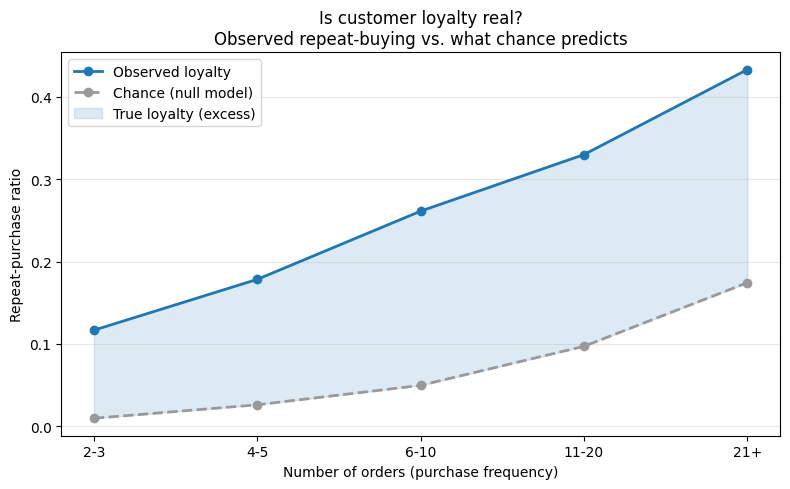

In [29]:
import matplotlib.pyplot as plt
import numpy as np

band = duckdb.sql("""
    WITH joined AS (
        SELECT l.orders, l.repeat_ratio AS observed, n.null_repeat_ratio AS null_r
        FROM loyalty l JOIN null_df n USING (customer_id)
    )
    SELECT
      CASE WHEN orders BETWEEN 2 AND 3 THEN 1
           WHEN orders BETWEEN 4 AND 5 THEN 2
           WHEN orders BETWEEN 6 AND 10 THEN 3
           WHEN orders BETWEEN 11 AND 20 THEN 4
           ELSE 5 END AS band_id,
      AVG(observed) AS observed,
      AVG(null_r)   AS null_r
    FROM joined GROUP BY band_id ORDER BY band_id
""").df()

labels = ["2-3", "4-5", "6-10", "11-20", "21+"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, band["observed"], "o-",  color="#1f77b4", lw=2, label="Observed loyalty")
ax.plot(x, band["null_r"],   "o--", color="#999999", lw=2, label="Chance (null model)")
ax.fill_between(x, band["null_r"], band["observed"], color="#1f77b4", alpha=0.15,
                label="True loyalty (excess)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Number of orders (purchase frequency)")
ax.set_ylabel("Repeat-purchase ratio")
ax.set_title("Is customer loyalty real?\nObserved repeat-buying vs. what chance predicts")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("loyalty_double_jeopardy.png", dpi=150, bbox_inches="tight")
plt.show()

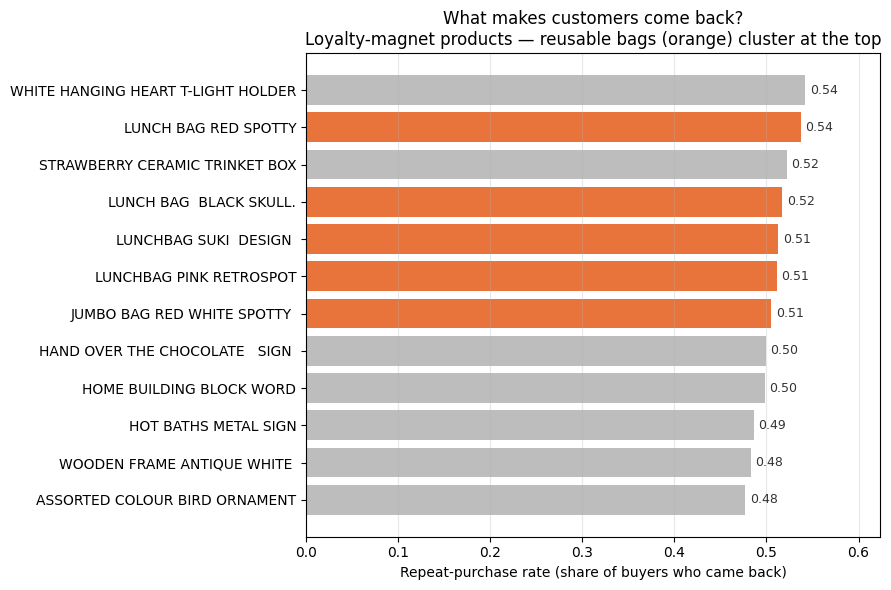

In [30]:
import matplotlib.pyplot as plt

# magnets の上位12を使う（barhは下から積むので逆順に並べ替え）
top = magnets.head(12).iloc[::-1]

# 説明に "BAG" を含む商品（ランチバッグ・ジャンボバッグ）をオレンジで強調
colors = ["#e8743b" if "BAG" in d else "#bdbdbd" for d in top["description"]]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top["description"], top["repeat_rate"], color=colors)

# 各バーの先に数値ラベル
for bar, val in zip(bars, top["repeat_rate"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9, color="#333333")

ax.set_xlabel("Repeat-purchase rate (share of buyers who came back)")
ax.set_title("What makes customers come back?\n"
             "Loyalty-magnet products — reusable bags (orange) cluster at the top")
ax.set_xlim(0, max(top["repeat_rate"]) * 1.15)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("loyalty_magnets.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
from google.colab import files
files.download("loyalty_double_jeopardy.png")
files.download("loyalty_magnets.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>